In [1]:
from pathlib import Path
import json, random, sys, time, os

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from PIL import Image

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebook":
    PROJECT_ROOT = PROJECT_ROOT.parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.wajib.rnn.RNN import RNNScratch
from src.wajib.lstm.LSTM import LSTMScratch, ImageCaptioningPipeline
from src.wajib.shared.layers import EmbeddingLayer, DenseLayer
from src.wajib.shared.preprocessing import (
    loadFlickr8kCaptions, loadVocabulary, cleanCaption, buildVocabulary, saveVocabulary, loadVocabulary, tokenizeCaption, padSequences
)
from src.wajib.shared.decoder import greedyDecode

# Untuk bleu dan meteor
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

I0000 00:00:1778849250.806557  124601 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
FEATURES_NPY  = PROJECT_ROOT / "src/wajib/weights/features/flickr8k_features.npy"
FEATURES_IDX  = PROJECT_ROOT / "src/wajib/weights/features/flickr8k_index.json"
CAPTIONS_FILE = PROJECT_ROOT / "data/flickr8k/captions.txt"
VOCAB_PATH    = PROJECT_ROOT / "src/wajib/weights/vocab.json"
DATA_DIR      = PROJECT_ROOT / "data/flickr8k"
FLICKR_DIR    = DATA_DIR / "Images"

RNN_WEIGHTS_DIR   = PROJECT_ROOT / "src/wajib/weights/rnn"
LSTM_WEIGHTS_DIR  = PROJECT_ROOT / "src/wajib/weights/lstm"
CNN_ENCODER_PATH  = PROJECT_ROOT / "src/wajib/weights/cnn"

EMBED_DIM    = 256
MAX_LEN      = 30
CNN_FEAT_DIM = 2048
TARGET_SIZE  = (299, 299)

features_matrix = np.load(FEATURES_NPY)
with open(FEATURES_IDX) as f:
    idxNames = json.load(f)

imageFeatures = {name: features_matrix[i] for i, name in enumerate(idxNames)}
print(f"Fitur: {len(imageFeatures)} gambar")

captionsDict = loadFlickr8kCaptions(str(CAPTIONS_FILE))
vocab = loadVocabulary(str(VOCAB_PATH))
id2word = {v: k for k, v in vocab.items()}
print(f"Caption: {len(captionsDict)} gambar")
print(f"Kosa kata: {len(vocab)} token")

# Bagi ulang data (sama seperti training)
allImages = list(captionsDict.keys())
random.seed(SEED)
random.shuffle(allImages)

trainImgs = set(allImages[:6000])
valImgs   = set(allImages[6000:7000])
testImgs  = set(allImages[7000:])

testCaps = {k: v for k, v in captionsDict.items() if k in testImgs}
print(f"Data uji: {len(testCaps)} gambar")

Fitur: 8091 gambar
Caption: 8091 gambar
Kosa kata: 4558 token
Data uji: 1091 gambar


In [3]:
rnnModels = sorted(
    RNN_WEIGHTS_DIR.glob("rnn_*.keras")
)

lstmModels = sorted(
    LSTM_WEIGHTS_DIR.glob("lstm_*.keras")
)

print(f"RNN models : {len(rnnModels)}")
print(f"LSTM models: {len(lstmModels)}")

if len(rnnModels) > 0:
    print("\nSample RNN:")
    print(rnnModels[0].name)

if len(lstmModels) > 0:
    print("\nSample LSTM:")
    print(lstmModels[0].name)

RNN models : 6
LSTM models: 0

Sample RNN:
rnn_1L_128h.keras


In [4]:
class RNNPipeline:
    def __init__(self, rnn, proj, embed, out, vocab, id2word, max_len=30):
        self.rnn = rnn
        self.proj = proj
        self.embed = embed
        self.out = out
        self.vocab = vocab
        self.id2word = id2word
        self.max_len = max_len

    def generateCaption(self, feat):
        hyp = greedyDecode(
            self.rnn, self.proj, self.embed, self.out, 
            feat, self.vocab, self.max_len
        )
        return ' '.join(hyp)

def buildRNNPipeline(modelPath, numLayers, vocab_path, max_len=30):
    vocab = loadVocabulary(vocab_path)
    id2word = {v: k for k, v in vocab.items()}

    model = tf.keras.models.load_model(str(modelPath))

    embed = EmbeddingLayer()
    embed.loadWeights(model.get_layer('embedding'))

    proj = DenseLayer()
    proj.loadWeights(model.get_layer('cnn_proj'))

    out = DenseLayer(activation='softmax')
    out.loadWeights(model.get_layer('output'))

    # RNN OR LSTM
    if 'lstm' in modelPath.name.lower():
        rnn = LSTMScratch()
        prefix = 'lstm'
    else:
        rnn = RNNScratch()
        prefix = 'rnn'

    rnn.loadWeights([
        model.get_layer(f'{prefix}_{i}')
        for i in range(numLayers)
    ])

    return RNNPipeline(rnn, proj, embed, out, vocab, id2word, max_len)

### Evaluation Loop

In [5]:
smooth = SmoothingFunction().method1


def evaluatePipeline(name, pipeline, testCaps):

    hypotheses = []
    references = []

    t0 = time.time()

    for i, (imgName, caps) in enumerate(testCaps.items()):

        if i % 200 == 0:
            print(
                f"{name}: {i}/{len(testCaps)}",
                end='\r'
            )

        if imgName not in imageFeatures:
            continue

        feat = imageFeatures[imgName]

        hyp = pipeline.generateCaption(feat)

        hypotheses.append(hyp.split())

        references.append([
            cap.split()
            for cap in caps
        ])

    elapsed = time.time() - t0

    bleu4 = corpus_bleu(
        references,
        hypotheses,
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smooth
    )

    meteorScores = []

    for refs, hyp in zip(references, hypotheses):

        meteorScores.append(
            max([
                meteor_score([ref], hyp)
                for ref in refs
            ])
        )

    meteor = np.mean(meteorScores)

    print(
        f"{name:<22} "
        f"BLEU-4={bleu4:.4f} "
        f"METEOR={meteor:.4f} "
        f"time={elapsed:.1f}s"
    )

    return {
        'bleu4': bleu4,
        'meteor': meteor,
        'time_s': elapsed,
    }

## Results Final

In [6]:
import traceback
import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score

nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('punkt', quiet=True)

allResults = {}
allModels = [
    ('RNN', rnnModels),
    ('LSTM', lstmModels),
]

for modelType, modelList in allModels:
    print("\n" + "=" * 70)
    print(f"{modelType} EXPERIMENTS")
    print("=" * 70)

    for modelPath in modelList:
        name = modelPath.stem
        numLayers = int(name.split('L')[0].split('_')[1])

        try:
            pipeline = buildRNNPipeline(
                modelPath=modelPath,
                numLayers=numLayers,
                vocab_path=VOCAB_PATH,
                max_len=MAX_LEN
            )

            result = evaluatePipeline(
                name,
                pipeline,
                testCaps
            )

            result['type'] = modelType
            allResults[name] = result

        except Exception as e:
            print(f"Gagal di {name}:")
            traceback.print_exc()


RNN EXPERIMENTS


I0000 00:00:1778849539.093763  124601 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1780 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


rnn_1L_128h            BLEU-4=0.1084 METEOR=0.2859 time=44.1s
rnn_1L_512h            BLEU-4=0.1267 METEOR=0.3085 time=159.1s
rnn_2L_128h            BLEU-4=0.1063 METEOR=0.2947 time=43.4s
rnn_2L_512h            BLEU-4=0.1058 METEOR=0.2968 time=169.3s
rnn_3L_128h            BLEU-4=0.0740 METEOR=0.2758 time=46.4s
rnn_3L_512h            BLEU-4=0.1106 METEOR=0.3021 time=196.2s

LSTM EXPERIMENTS


### Summary and Best LSTM/RNN

In [7]:
resultsDf = pd.DataFrame(allResults).T
resultsDf['bleu4']  = resultsDf['bleu4'].astype(float)
resultsDf['meteor'] = resultsDf['meteor'].astype(float)
resultsDf['time_s'] = resultsDf['time_s'].astype(float)
resultsDf = resultsDf.sort_values('bleu4', ascending=False)
display(resultsDf)

rnnDf  = resultsDf[resultsDf['type'] == 'RNN']
lstmDf = resultsDf[resultsDf['type'] == 'LSTM']

bestRnn  = rnnDf.index[0]  if len(rnnDf)  > 0 else None
bestLstm = lstmDf.index[0] if len(lstmDf) > 0 else None

print(f"Best RNN : {bestRnn}")
print(f"Best LSTM: {bestLstm}")

,bleu4,meteor,time_s,type
rnn_1L_512h,0.126670,0.308488,159.076674,RNN
rnn_3L_512h,0.110640,0.302111,196.234294,RNN
rnn_1L_128h,0.108378,0.285889,44.123798,RNN
rnn_2L_128h,0.106273,0.294718,43.403730,RNN
rnn_2L_512h,0.105820,0.296807,169.322860,RNN
rnn_3L_128h,0.073980,0.275785,46.386753,RNN


Best RNN : rnn_1L_512h
Best LSTM: None


/tmp/ipykernel_124601/3512813439.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True)


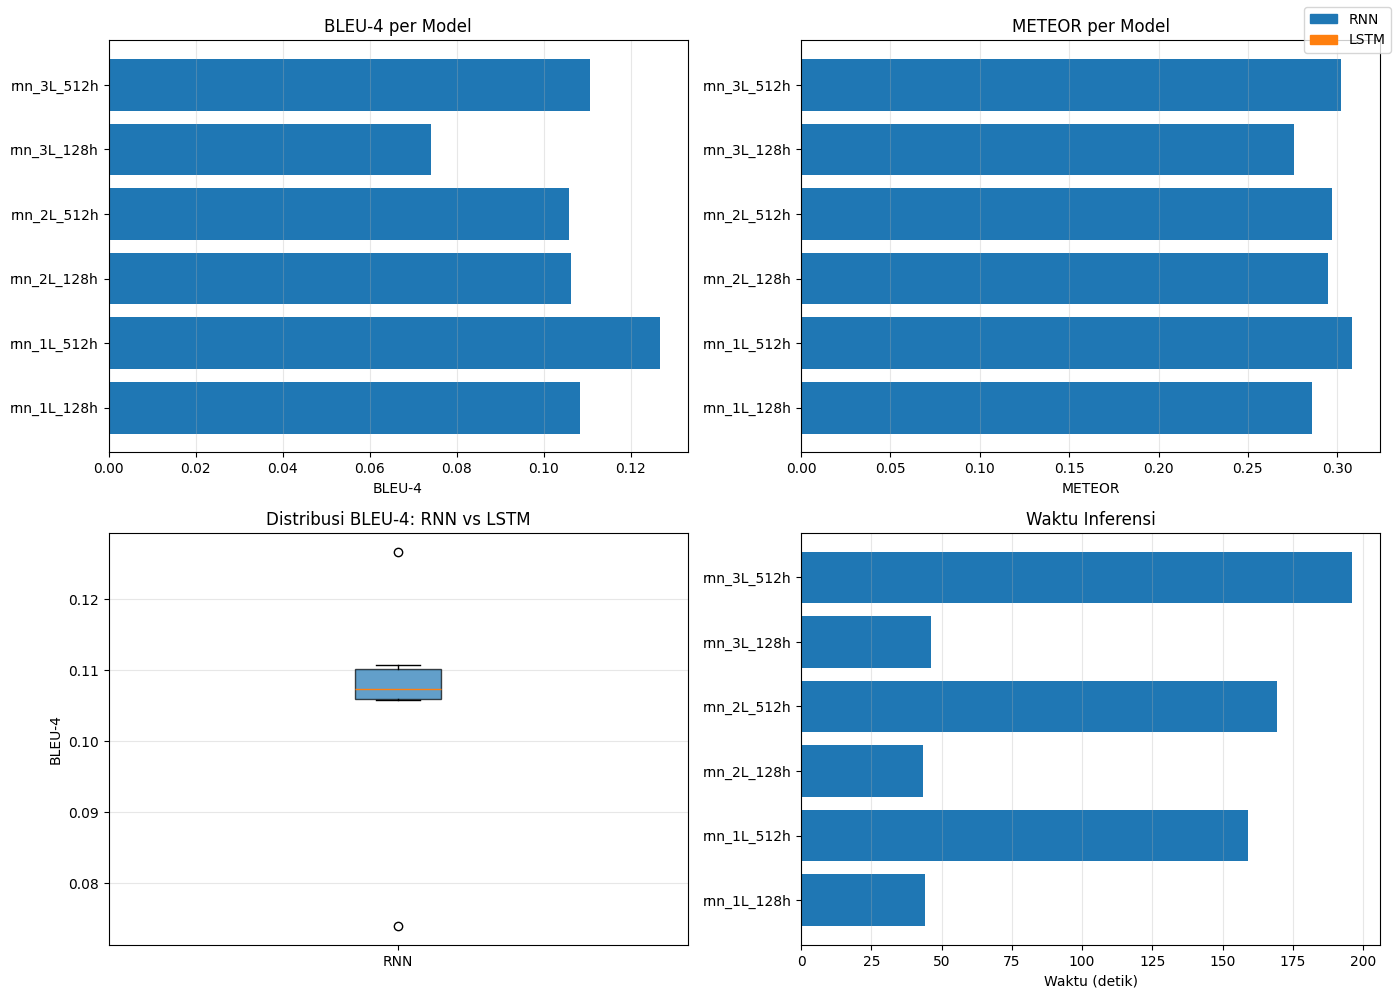

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

models = list(allResults.keys())
colors = ['#1f77b4' if allResults[m]['type'] == 'RNN' else '#ff7f0e' for m in models]

# BLEU-4
ax = axes[0, 0]
ax.barh(models, [allResults[m]['bleu4'] for m in models], color=colors)
ax.set_xlabel('BLEU-4')
ax.set_title('BLEU-4 per Model')
ax.grid(axis='x', alpha=0.3)

# METEOR
ax = axes[0, 1]
ax.barh(models, [allResults[m]['meteor'] for m in models], color=colors)
ax.set_xlabel('METEOR')
ax.set_title('METEOR per Model')
ax.grid(axis='x', alpha=0.3)

# Box plot RNN vs LSTM
ax = axes[1, 0]
rnnBleus  = [allResults[n]['bleu4'] for n in allResults if allResults[n]['type'] == 'RNN']
lstmBleus = [allResults[n]['bleu4'] for n in allResults if allResults[n]['type'] == 'LSTM']
data = [x for x in [rnnBleus, lstmBleus] if x]
labels = [l for l, x in zip(['RNN', 'LSTM'], [rnnBleus, lstmBleus]) if x]
bp = ax.boxplot(data, labels=labels, patch_artist=True)
for patch, color in zip(bp['boxes'], ['#1f77b4', '#ff7f0e']):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_ylabel('BLEU-4')
ax.set_title('Distribusi BLEU-4: RNN vs LSTM')
ax.grid(axis='y', alpha=0.3)

# Waktu inferensi
ax = axes[1, 1]
ax.barh(models, [allResults[m]['time_s'] for m in models], color=colors)
ax.set_xlabel('Waktu (detik)')
ax.set_title('Waktu Inferensi')
ax.grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
legend = [Patch(color='#1f77b4', label='RNN'), Patch(color='#ff7f0e', label='LSTM')]
fig.legend(handles=legend, loc='upper right')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "src/wajib/weights/pipeline_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# Keras vs Scratch

In [9]:
def generateCaptionKeras(model, feat, vocab, id2word, max_len=30):
    start_token = vocab['<start>']
    end_token   = vocab['<end>']

    feat_np = feat[np.newaxis]  # (1, 2048) numpy
    seq = [start_token]

    for _ in range(max_len):
        padded = tf.keras.utils.pad_sequences([seq], maxlen=max_len, padding='post')
        preds  = model.predict([feat_np, padded], verbose=0)
        next_idx = int(np.argmax(preds[0, len(seq) - 1]))

        if next_idx == end_token:
            break
        seq.append(next_idx)

    words = [id2word[i] for i in seq[1:] if i in id2word]
    return ' '.join(words)

I0000 00:00:1778850228.259977  128137 service.cc:153] XLA service 0x5592da0ac740 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778850228.260022  128137 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce GTX 1650, Compute Capability 7.5 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1778850228.376958  128137 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778850228.591614  128137 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1778850230.456889  128137 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



rnn_1L_512h (RNN)
  Keras   => BLEU-4=0.0108  waktu=1473.3s
  Scratch => BLEU-4=0.1267  waktu=162.2s
  Delta BLEU-4: 0.115917


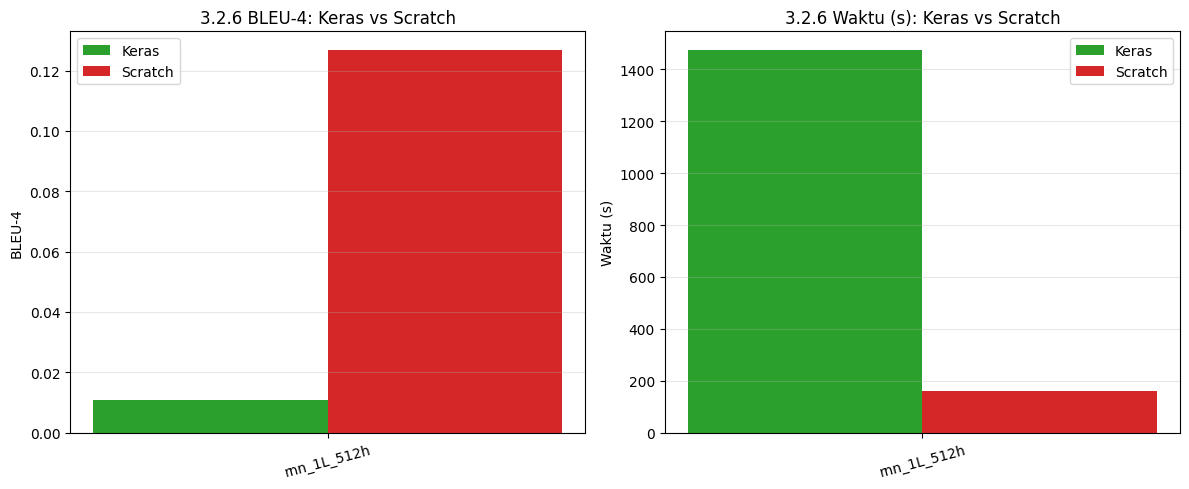

In [10]:
kerasVsScratch = {}

for bestName in filter(None, [bestRnn, bestLstm]):
    numLayers = int(bestName.split('L')[0].split('_')[1])
    modelDir  = RNN_WEIGHTS_DIR if 'rnn' in bestName else LSTM_WEIGHTS_DIR
    modelPath = modelDir / f"{bestName}.keras"
    modelType = allResults[bestName]['type']

    kerasModel      = tf.keras.models.load_model(str(modelPath))
    scratchPipeline = buildRNNPipeline(modelPath, numLayers, VOCAB_PATH, MAX_LEN)

    hypsKeras, hypsScratch, refsAll = [], [], []
    tKeras = tScratch = 0.0

    for imgName, caps in testCaps.items():
        if imgName not in imageFeatures:
            continue
        feat = imageFeatures[imgName]
        refsAll.append([cap.split() for cap in caps])

        t0 = time.time()
        hypsKeras.append(generateCaptionKeras(kerasModel, feat, vocab, id2word, MAX_LEN).split())
        tKeras += time.time() - t0

        t0 = time.time()
        hypsScratch.append(scratchPipeline.generateCaption(feat).split())
        tScratch += time.time() - t0

    bleuKeras   = corpus_bleu(refsAll, hypsKeras,   weights=(0.25,)*4, smoothing_function=smooth)
    bleuScratch = corpus_bleu(refsAll, hypsScratch, weights=(0.25,)*4, smoothing_function=smooth)

    kerasVsScratch[bestName] = {
        'keras_bleu4': bleuKeras,   'keras_time': tKeras,
        'scratch_bleu4': bleuScratch, 'scratch_time': tScratch,
        'type': modelType,
    }
    print(f"\n{bestName} ({modelType})")
    print(f"  Keras   => BLEU-4={bleuKeras:.4f}  waktu={tKeras:.1f}s")
    print(f"  Scratch => BLEU-4={bleuScratch:.4f}  waktu={tScratch:.1f}s")
    print(f"  Delta BLEU-4: {abs(bleuKeras - bleuScratch):.6f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
names = list(kerasVsScratch.keys())

for ax, (metric, label) in zip(axes, [('bleu4', 'BLEU-4'), ('time', 'Waktu (s)')]):
    x = np.arange(len(names))
    w = 0.35
    ax.bar(x - w/2, [kerasVsScratch[n][f'keras_{metric}']   for n in names], w, label='Keras',
color='#2ca02c')
    ax.bar(x + w/2, [kerasVsScratch[n][f'scratch_{metric}'] for n in names], w, label='Scratch',
color='#d62728')
    ax.set_xticks(x); ax.set_xticklabels(names, rotation=15)
    ax.set_title(f'3.2.6 {label}: Keras vs Scratch')
    ax.set_ylabel(label)
    ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "src/wajib/weights/keras_vs_scratch.png", dpi=150, bbox_inches='tight')
plt.show()

### Pengaruh Panjang Max Caption

  max_len=10 → BLEU-4=0.1382
  max_len=20 → BLEU-4=0.1267
  max_len=30 → BLEU-4=0.1267
  max_len=40 → BLEU-4=0.1267
  max_len=50 → BLEU-4=0.1267


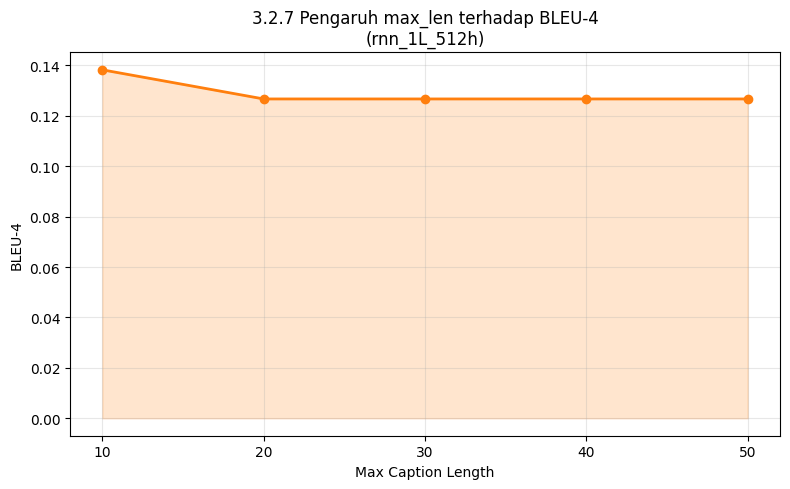


max_len terbaik: 10 (BLEU-4=0.1382)


In [11]:
bestOverall   = resultsDf.index[0]
numLayersBest = int(bestOverall.split('L')[0].split('_')[1])
modelDirBest  = RNN_WEIGHTS_DIR if 'rnn' in bestOverall else LSTM_WEIGHTS_DIR

maxLenResults = {}

for maxLenTest in [10, 20, 30, 40, 50]:
    pipeline = buildRNNPipeline(
        modelDirBest / f"{bestOverall}.keras",
        numLayersBest, VOCAB_PATH, maxLenTest
    )
    hyps, refs = [], []
    for imgName, caps in testCaps.items():
        if imgName not in imageFeatures:
            continue
        hyps.append(pipeline.generateCaption(imageFeatures[imgName]).split())
        refs.append([cap.split() for cap in caps])

    bleu4 = corpus_bleu(refs, hyps, weights=(0.25,)*4, smoothing_function=smooth)
    maxLenResults[maxLenTest] = bleu4
    print(f"  max_len={maxLenTest:2d} → BLEU-4={bleu4:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(maxLenResults.keys()), list(maxLenResults.values()),
        marker='o', linewidth=2, color='#ff7f0e')
ax.fill_between(list(maxLenResults.keys()), list(maxLenResults.values()), alpha=0.2, color='#ff7f0e')
ax.set_xlabel('Max Caption Length')
ax.set_ylabel('BLEU-4')
ax.set_title(f'3.2.7 Pengaruh max_len terhadap BLEU-4\n({bestOverall})')
ax.set_xticks(list(maxLenResults.keys()))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "src/wajib/weights/maxlen_variation.png", dpi=150, bbox_inches='tight')
plt.show()

bestLen = max(maxLenResults, key=maxLenResults.get)
print(f"\nmax_len terbaik: {bestLen} (BLEU-4={maxLenResults[bestLen]:.4f})")